# Statistical Analysis of the SP6 and SP9 Data
by Adam Fedor

2025 Fall

## Importing the necessary libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io as sio
%matplotlib widget

## Info about the data:
**Simultan in vitro Intracellular (patch clamp) and Extracellular (Spiky Probe) Recordings**

**SP6:**
- CA1 Pyramidal cell from in vitro rodent brain tissue
- Time of recording: 2018. 06. 28.
- Number of recordings: 4
    - Holding currents: +80 pA, +80 pA, +25 pA, 0 pA
    - BB compensation: 38.6 MOhm, off, off, off
    - IC spike counts: 674, 788, 232, 311
- Probe: spiky_050_01
- Means of data analysis:
    - spike sorting with KiloSort 2
    - manual curation with the phy2 GUI

**SP9**
- CA2 Pyramidal cell from in vitro rodent brain tissue
- Time of recording: 2022. 02. 15.
- Number of recordings: 3
    - Holding currents: +120 pA, +80 pA, +80 pA
    - BB compensation: 22 MOhm, off, off
    - IC spike counts: 822, 760, 773
- Probe: spiky_025_02
- Means of data analysis:
    - spike sorting with KiloSort 2
    - manual curation with the phy2 GUI

In [2]:
# Here we give the path names for the data files
# First we read the SP6 files
sp6_cluster_info = {}# Dictionary to hold file paths

# Dictionaries to hold extracted data
sp6_cluster_ids = {}
sp6_amplitudes = {}
sp6_KSlabels = {}
sp6_channel_ids = {}
sp6_num_spikes = {}
sp6_cluster_types = {}

for i in range(1, 5):  # Loop over recordings 01, 02, 03, 04
    sp6_cluster_info[i] = f'../sp_6_20180628/spike_sorting_Thresh_9_9/Data/{i:02d}/cluster_info.tsv'
    # Load the cluster information from the TSV file - mind the header line!
    cluster_data = pd.read_csv(sp6_cluster_info[i], sep='\t')
    print(f"This is the head and data from SP6 recording {i:02d}:")
    print("\n")
    print(cluster_data.head())
    # Extract relevant columns
    sp6_cluster_ids[i] = cluster_data['cluster_id'].values
    sp6_amplitudes[i] = cluster_data['Amplitude'].values
    sp6_KSlabels[i] = cluster_data['KSLabel'].values  # e.g., 'good', 'mua', 'noise' - labeled by Kilosort
    sp6_channel_ids[i] = cluster_data['ch'].values
    sp6_num_spikes[i] = cluster_data['n_spikes'].values
    sp6_cluster_types[i] = cluster_data['group'].values # e.g., 'good', 'mua', 'noise' - labeled by the Manual Curator
    
    print(f"Total clusters: {len(sp6_cluster_ids[i])}")
    print(sp6_num_spikes[i].shape)
    print(sp6_num_spikes[i])
    print(sp6_cluster_types[i])
    print("\n")
    print("="*80)
    print("\n")

This is the head and data from SP6 recording 01:


   cluster_id  Amplitude  ContamPct KSLabel        amp  ch  depth        fr  \
0           0      205.3      100.0    good  11.702219   1   31.0  0.022227   
1           1      118.0        0.0     mua   8.360383   1   31.0  0.022227   
2           4      195.3      100.0    good  15.561150   2   30.0  0.038897   
3           7      274.2        0.0    good  12.971405   6   26.0  3.889667   
4           9      150.7      100.0    good   9.206478  11   21.0  0.011113   

   group  n_spikes  sh  
0   good         4   0  
1  noise         4   0  
2  noise         7   0  
3   good       700   0  
4  noise         2   0  
Total clusters: 20
(20,)
[  4   4   7 700   2   2   3   2   1   1   6  17   1   5   1  17   1   9
   1   3]
['good' 'noise' 'noise' 'good' 'noise' 'noise' 'noise' 'noise' 'noise'
 'noise' 'noise' 'good' 'noise' 'good' 'noise' 'good' 'noise' 'good'
 'noise' 'noise']




This is the head and data from SP6 recording 02:


   

In [3]:
# Here we give the path names for the data files
# Now we read the SP9 files
sp9_cluster_info = {}# Dictionary to hold file paths

# Dictionaries to hold extracted data
sp9_cluster_ids = {}
sp9_amplitudes = {}
sp9_KSlabels = {}
sp9_channel_ids = {}
sp9_num_spikes = {}
sp9_cluster_types = {}

for i in range(1, 4):  # Loop over recordings 01, 02, 03
    sp9_cluster_info[i] = f'../sp_9_20220215/spike_sorting_Thresh_9_9/Data/{i:02d}/cluster_info.tsv'
    # Load the cluster information from the TSV file - mind the header line!
    cluster_data = pd.read_csv(sp9_cluster_info[i], sep='\t')
    print(f"This is the head and data from SP9 recording {i:02d}:")
    print("\n")
    print(cluster_data.head())
    # Extract relevant columns
    sp9_cluster_ids[i] = cluster_data['cluster_id'].values
    sp9_amplitudes[i] = cluster_data['Amplitude'].values
    sp9_KSlabels[i] = cluster_data['KSLabel'].values  # e.g., 'good', 'mua', 'noise' - labeled by Kilosort
    sp9_channel_ids[i] = cluster_data['ch'].values
    sp9_num_spikes[i] = cluster_data['n_spikes'].values
    sp9_cluster_types[i] = cluster_data['group'].values # e.g., 'good', 'mua', 'noise' - labeled by the Manual Curator

    print(f"Total clusters: {len(sp9_cluster_ids[i])}")
    print(sp9_num_spikes[i].shape)
    print(sp9_num_spikes[i])
    print(sp9_cluster_types[i])
    print("\n")
    print("="*80)
    print("\n")

This is the head and data from SP9 recording 01:


   cluster_id  Amplitude  ContamPct KSLabel        amp  ch  depth        fr  \
0           0      207.9      100.0    good  11.001548   1    2.0  0.011113   
1           1      186.0      100.0    good  12.368676   1    2.0  0.100020   
2           2      218.2        0.0     mua  14.220893   1    2.0  0.222267   
3           3      186.1      100.0    good  13.362687   1    2.0  0.100020   
4           4      226.7        0.0     mua  10.779371   7    8.0  0.227823   

   group  n_spikes  sh  
0  noise         2   0  
1  noise        18   0  
2  noise        40   0  
3  noise        18   0  
4   good        41   0  
Total clusters: 35
(35,)
[   2   18   40   18   41   73    8    5   13    4    5  618   25    6
    5   26    9    3 2970    6    6  200   70    4    7  535    5   13
    8  124    5   93   26  836    9]
['noise' 'noise' 'noise' 'noise' 'good' 'mua' 'noise' 'noise' 'noise'
 'noise' 'noise' 'mua' 'good' 'noise' 'noise' 'mua

## Data Analysis and Statistics

### SP6

In [4]:
# We plot the .mat file with the 32 channels of EC and 1 channel of IC recording from the EC recorder
# as well as the IC spike timestamps from the .ev2 file
# for the SP6 so we can see the waveforms, if it is possible!

# Load the .mat file for each SP6 recording
mat_file_path = {}
for i in range(1, 5):
    mat_file_path[i-1] = f'../sp_6_20180628/{i:02d}.mat'

mat_sp6_01 = sio.loadmat(mat_file_path[0])
mat_sp6_02 = sio.loadmat(mat_file_path[1])
mat_sp6_03 = sio.loadmat(mat_file_path[2])
mat_sp6_04 = sio.loadmat(mat_file_path[3])

print("SP6 .mat file keys for recording 01:", mat_sp6_01.keys())

SP6 .mat file keys for recording 01: dict_keys(['__header__', '__version__', '__globals__', 'simultan_data'])


In [5]:
# Access our matrix
sp6_01_data = mat_sp6_01['simultan_data']  # will be a (33, 3599280) numpy array
sp6_02_data = mat_sp6_02['simultan_data']
sp6_03_data = mat_sp6_03['simultan_data']
sp6_04_data = mat_sp6_04['simultan_data']
print(sp6_01_data.shape)  # (33, 3599280)
print(sp6_02_data.shape)
print(sp6_03_data.shape)
print(sp6_04_data.shape)

(33, 3599280)
(33, 3599280)
(33, 3599280)
(33, 3599280)


In [6]:
# Split the data into EC and IC
sp6_01_EC = sp6_01_data[:32, :]  # First 32 channels are EC
sp6_01_IC = sp6_01_data[32, :]   # Last channel is IC
sp6_02_EC = sp6_02_data[:32, :]  # First 32 channels are EC
sp6_02_IC = sp6_02_data[32, :]   # Last channel is IC
sp6_03_EC = sp6_03_data[:32, :]  # First 32 channels are EC
sp6_03_IC = sp6_03_data[32, :]   # Last channel is IC
sp6_04_EC = sp6_04_data[:32, :]  # First 32 channels are EC
sp6_04_IC = sp6_04_data[32, :]   # Last channel is IC

print("SP6 recording 01 EC shape:", sp6_01_EC.shape)
print("SP6 recording 01 IC shape:", sp6_01_IC.shape)

SP6 recording 01 EC shape: (32, 3599280)
SP6 recording 01 IC shape: (3599280,)


In [7]:
# Load the timestamps from the .ev2 files
sp6_01_spiketimes = np.loadtxt('/Volumes/AFedor_T7/TTK-NeuroData/sp_6_20180628/01.ev2', usecols=5)
sp6_02_spiketimes = np.loadtxt('/Volumes/AFedor_T7/TTK-NeuroData/sp_6_20180628/02.ev2', usecols=5)
sp6_03_spiketimes = np.loadtxt('/Volumes/AFedor_T7/TTK-NeuroData/sp_6_20180628/03.ev2', usecols=5)
sp6_04_spiketimes = np.loadtxt('/Volumes/AFedor_T7/TTK-NeuroData/sp_6_20180628/04.ev2', usecols=5)
print(sp6_01_spiketimes.shape)  # (678,)
print(sp6_02_spiketimes.shape)
print(sp6_03_spiketimes.shape)
print(sp6_04_spiketimes.shape)

print(sp6_01_spiketimes[:10])  # Print first 10 spike times

(678,)
(793,)
(235,)
(312,)
[ 1966.  5459.  9246. 13240. 17142. 23034. 27752. 33045. 37743. 42182.]


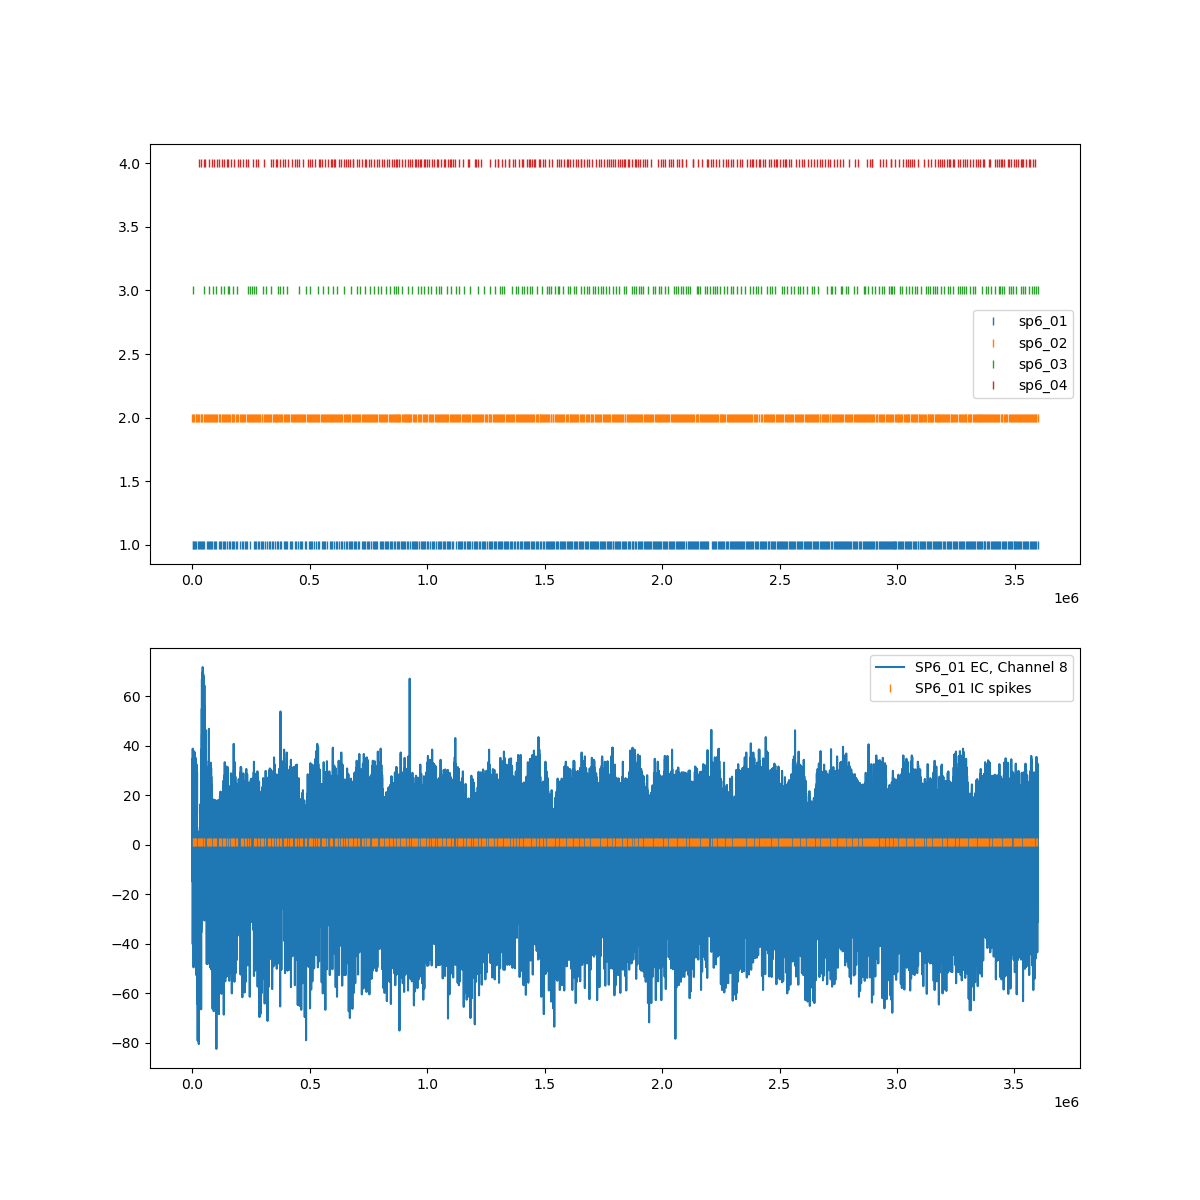

In [8]:
# Plotting some of the data and spike times to see how they look
f, axes = plt.subplots(2, 1, figsize=(12, 12))
axes[0].plot(sp6_01_spiketimes, np.ones_like(sp6_01_spiketimes), '|', label='sp6_01')
axes[0].plot(sp6_02_spiketimes, np.ones_like(sp6_02_spiketimes)*2, '|', label='sp6_02')
axes[0].plot(sp6_03_spiketimes, np.ones_like(sp6_03_spiketimes)*3, '|', label='sp6_03')
axes[0].plot(sp6_04_spiketimes, np.ones_like(sp6_04_spiketimes)*4, '|', label='sp6_04')
axes[0].legend()

axes[1].plot(sp6_01_EC[7], label='SP6_01 EC, Channel 8')
axes[1].plot(sp6_01_spiketimes, np.ones_like(sp6_01_spiketimes), '|', label='SP6_01 IC spikes')
axes[1].legend()
plt.show()

In [9]:
# Now I will cut the EC recordings into +- 100ms epochs around each IC spike time
epoch_window = 0.1  # 100 ms
sampling_rate = 20000  # 20 kHz
half_window_size = int(epoch_window * sampling_rate)
print("Half window size in samples:", half_window_size)
print("\n")

# For SP6_01
sp6_01_epochs = np.zeros((32, sp6_01_spiketimes.size, half_window_size * 2))  # Initialize empty array for epochs
for i, spike_time in enumerate(sp6_01_spiketimes):
    start_index = int(spike_time - half_window_size)
    end_index = int(spike_time + half_window_size)
    if start_index >= 0 and end_index <= sp6_01_EC.shape[1]:
        epoch = sp6_01_EC[:, start_index:end_index]
        sp6_01_epochs[:, i, :] = epoch
    elif start_index < 0:
        epoch = sp6_01_EC[:, 0:end_index]
        sp6_01_epochs[:, i, :epoch.shape[1]] = epoch
    elif end_index > sp6_01_EC.shape[1]:
        epoch = sp6_01_EC[:, start_index:sp6_01_EC.shape[1]]
        sp6_01_epochs[:, i, :epoch.shape[1]] = epoch

print("SP6_01 IC - number of spikes:", sp6_01_spiketimes.size)
print("SP6_01_epochs shape:", sp6_01_epochs.shape)  # (32, num_spikes, 4000)
print("\n")

# For SP6_02
sp6_02_epochs = np.zeros((32, sp6_02_spiketimes.size, half_window_size * 2))  # Initialize empty array for epochs
for i, spike_time in enumerate(sp6_02_spiketimes):
    start_index = int(spike_time - half_window_size)
    end_index = int(spike_time + half_window_size)
    if start_index >= 0 and end_index <= sp6_02_EC.shape[1]:
        epoch = sp6_02_EC[:, start_index:end_index]
        sp6_02_epochs[:, i, :] = epoch
    elif start_index < 0:
        epoch = sp6_02_EC[:, 0:end_index]
        sp6_02_epochs[:, i, :epoch.shape[1]] = epoch
    elif end_index > sp6_02_EC.shape[1]:
        epoch = sp6_02_EC[:, start_index:sp6_02_EC.shape[1]]
        sp6_02_epochs[:, i, :epoch.shape[1]] = epoch

print("SP6_02 IC - number of spikes:", sp6_02_spiketimes.size)
print("SP6_02_epochs shape:", sp6_02_epochs.shape)  # (32, num_spikes, 4000)
print("\n")

# For SP6_03
sp6_03_epochs = np.zeros((32, sp6_03_spiketimes.size, half_window_size * 2))  # Initialize empty array for epochs
for i, spike_time in enumerate(sp6_03_spiketimes):
    start_index = int(spike_time - half_window_size)
    end_index = int(spike_time + half_window_size)
    if start_index >= 0 and end_index <= sp6_03_EC.shape[1]:
        epoch = sp6_03_EC[:, start_index:end_index]
        sp6_03_epochs[:, i, :] = epoch
    elif start_index < 0:
        epoch = sp6_03_EC[:, 0:end_index]
        sp6_03_epochs[:, i, :epoch.shape[1]] = epoch
    elif end_index > sp6_03_EC.shape[1]:
        epoch = sp6_03_EC[:, start_index:sp6_03_EC.shape[1]]
        sp6_03_epochs[:, i, :epoch.shape[1]] = epoch

print("SP6_03 IC - number of spikes:", sp6_03_spiketimes.size)
print("SP6_03_epochs shape:", sp6_03_epochs.shape)  # (32, num_spikes, 4000)
print("\n")

# For SP6_04
sp6_04_epochs = np.zeros((32, sp6_04_spiketimes.size, half_window_size * 2))  # Initialize empty array for epochs
for i, spike_time in enumerate(sp6_04_spiketimes):
    start_index = int(spike_time - half_window_size)
    end_index = int(spike_time + half_window_size)
    if start_index >= 0 and end_index <= sp6_04_EC.shape[1]:
        epoch = sp6_04_EC[:, start_index:end_index]
        sp6_04_epochs[:, i, :] = epoch
    elif start_index < 0:
        epoch = sp6_04_EC[:, 0:end_index]
        sp6_04_epochs[:, i, :epoch.shape[1]] = epoch
    elif end_index > sp6_04_EC.shape[1]:
        epoch = sp6_04_EC[:, start_index:sp6_04_EC.shape[1]]
        sp6_04_epochs[:, i, :epoch.shape[1]] = epoch

print("SP6_04 IC - number of spikes:", sp6_04_spiketimes.size)
print("SP6_04_epochs shape:", sp6_04_epochs.shape)  # (32, num_spikes, 4000)

Half window size in samples: 2000


SP6_01 IC - number of spikes: 678
SP6_01_epochs shape: (32, 678, 4000)


SP6_02 IC - number of spikes: 793
SP6_02_epochs shape: (32, 793, 4000)


SP6_03 IC - number of spikes: 235
SP6_03_epochs shape: (32, 235, 4000)


SP6_04 IC - number of spikes: 312
SP6_04_epochs shape: (32, 312, 4000)


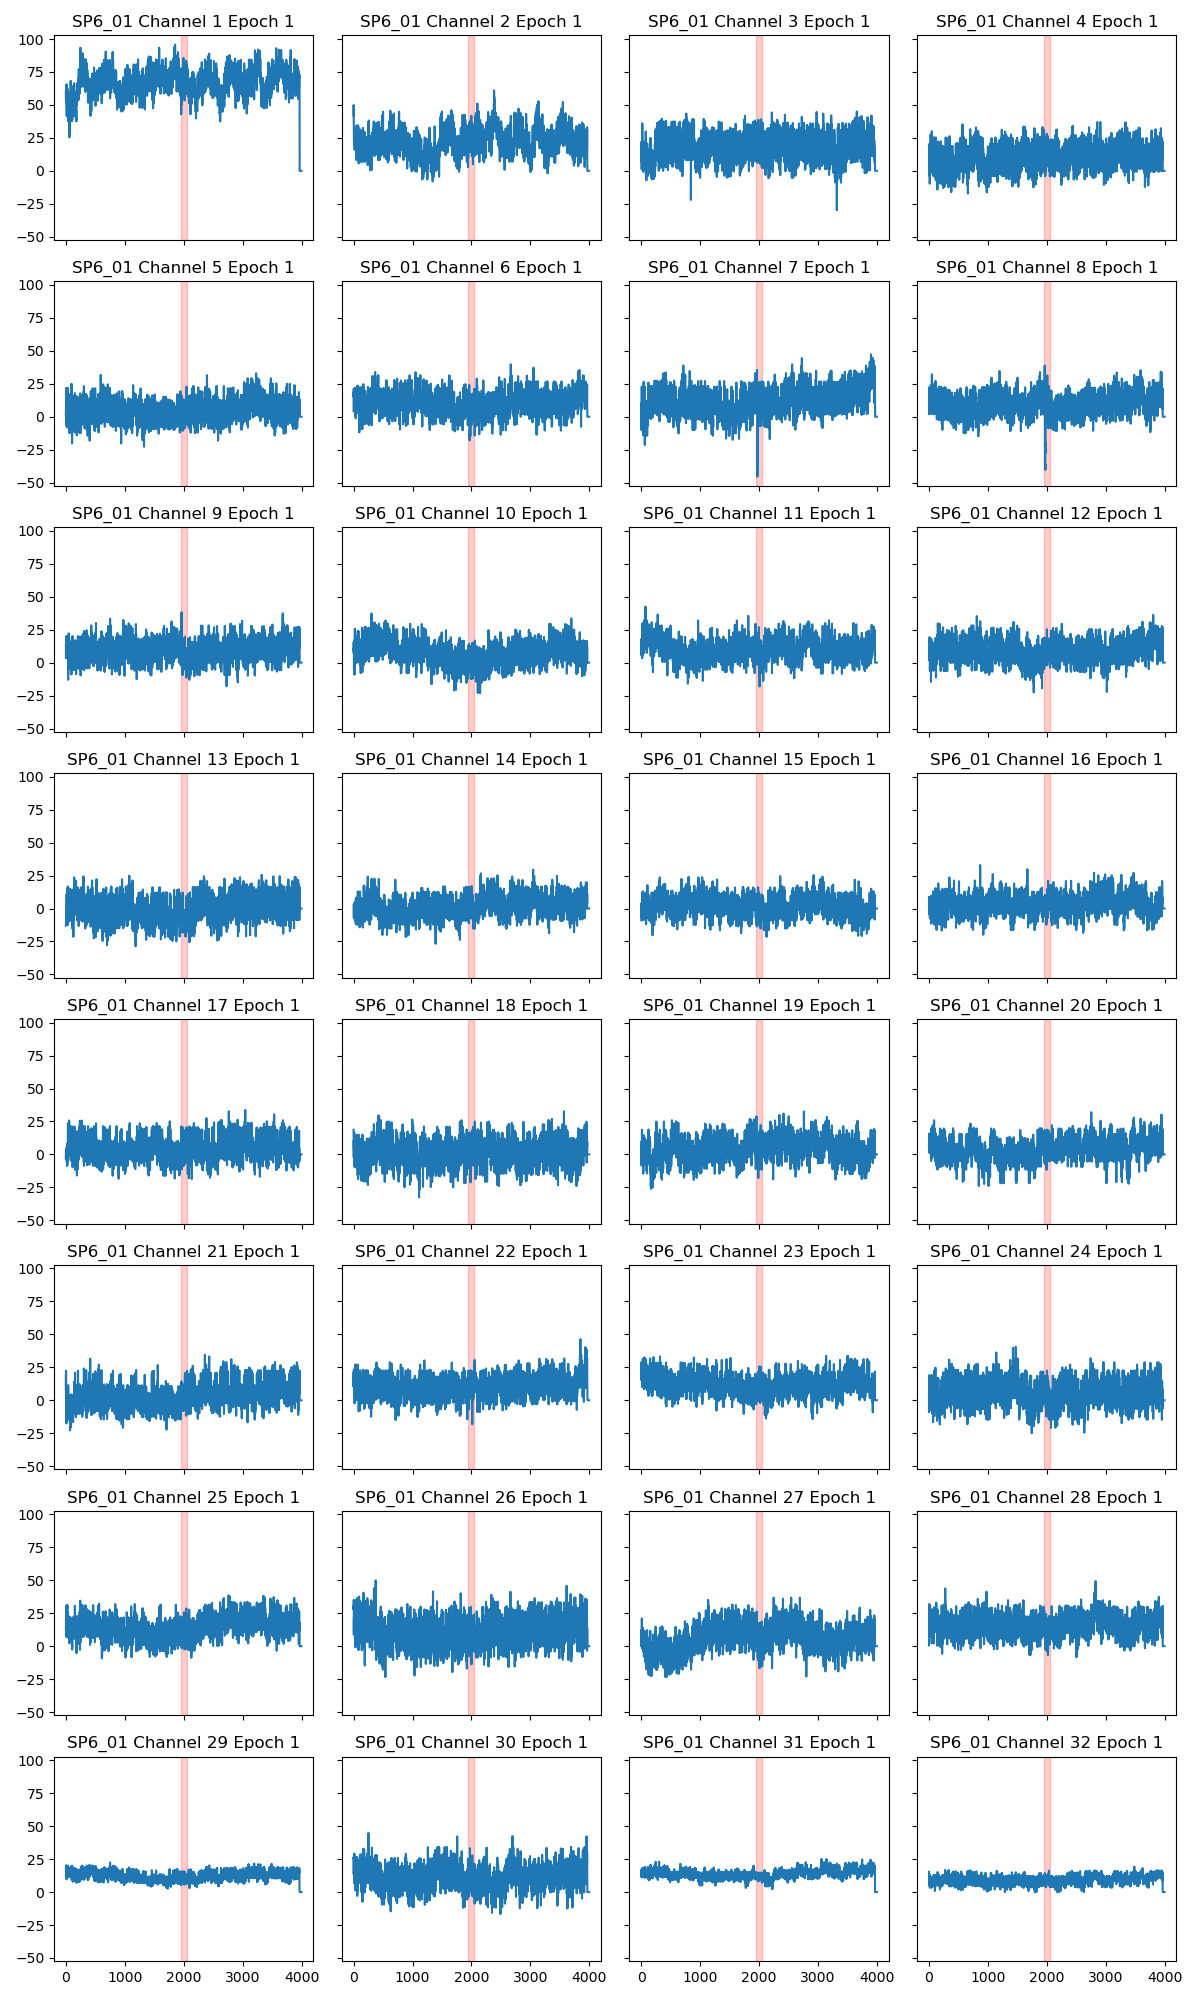

In [10]:
# Plotting an individual epoch for all channels for SP6_01
fig, axes = plt.subplots(8, 4, figsize=(12, 20), sharex=True, sharey=True)
num_of_ch = sp6_01_epochs.shape[0]
for ch in range(32):
    ax = axes[ch // 4, ch % 4]
    ax.plot(sp6_01_epochs[ch, 0, :])
    ax.set_title(f'SP6_01 Channel {ch+1} Epoch 1')
    # ax.axvline(half_window_size, color='r', linestyle='--')  # Mark the spike time
    ax.axvspan(half_window_size-50, half_window_size+50, alpha = 0.2, color='r')
plt.tight_layout()
plt.show()

In [11]:
# Averaging all epochs for each channel in each recording
# to see the average waveform around IC spiketimes
sp6_01_avg_epochs = np.mean(sp6_01_epochs, axis=1)  # Shape: (32, 4000)
sp6_02_avg_epochs = np.mean(sp6_02_epochs, axis=1)  # Shape: (32, 4000)
sp6_03_avg_epochs = np.mean(sp6_03_epochs, axis=1)  # Shape: (32, 4000)
sp6_04_avg_epochs = np.mean(sp6_04_epochs, axis=1)  # Shape: (32, 4000)

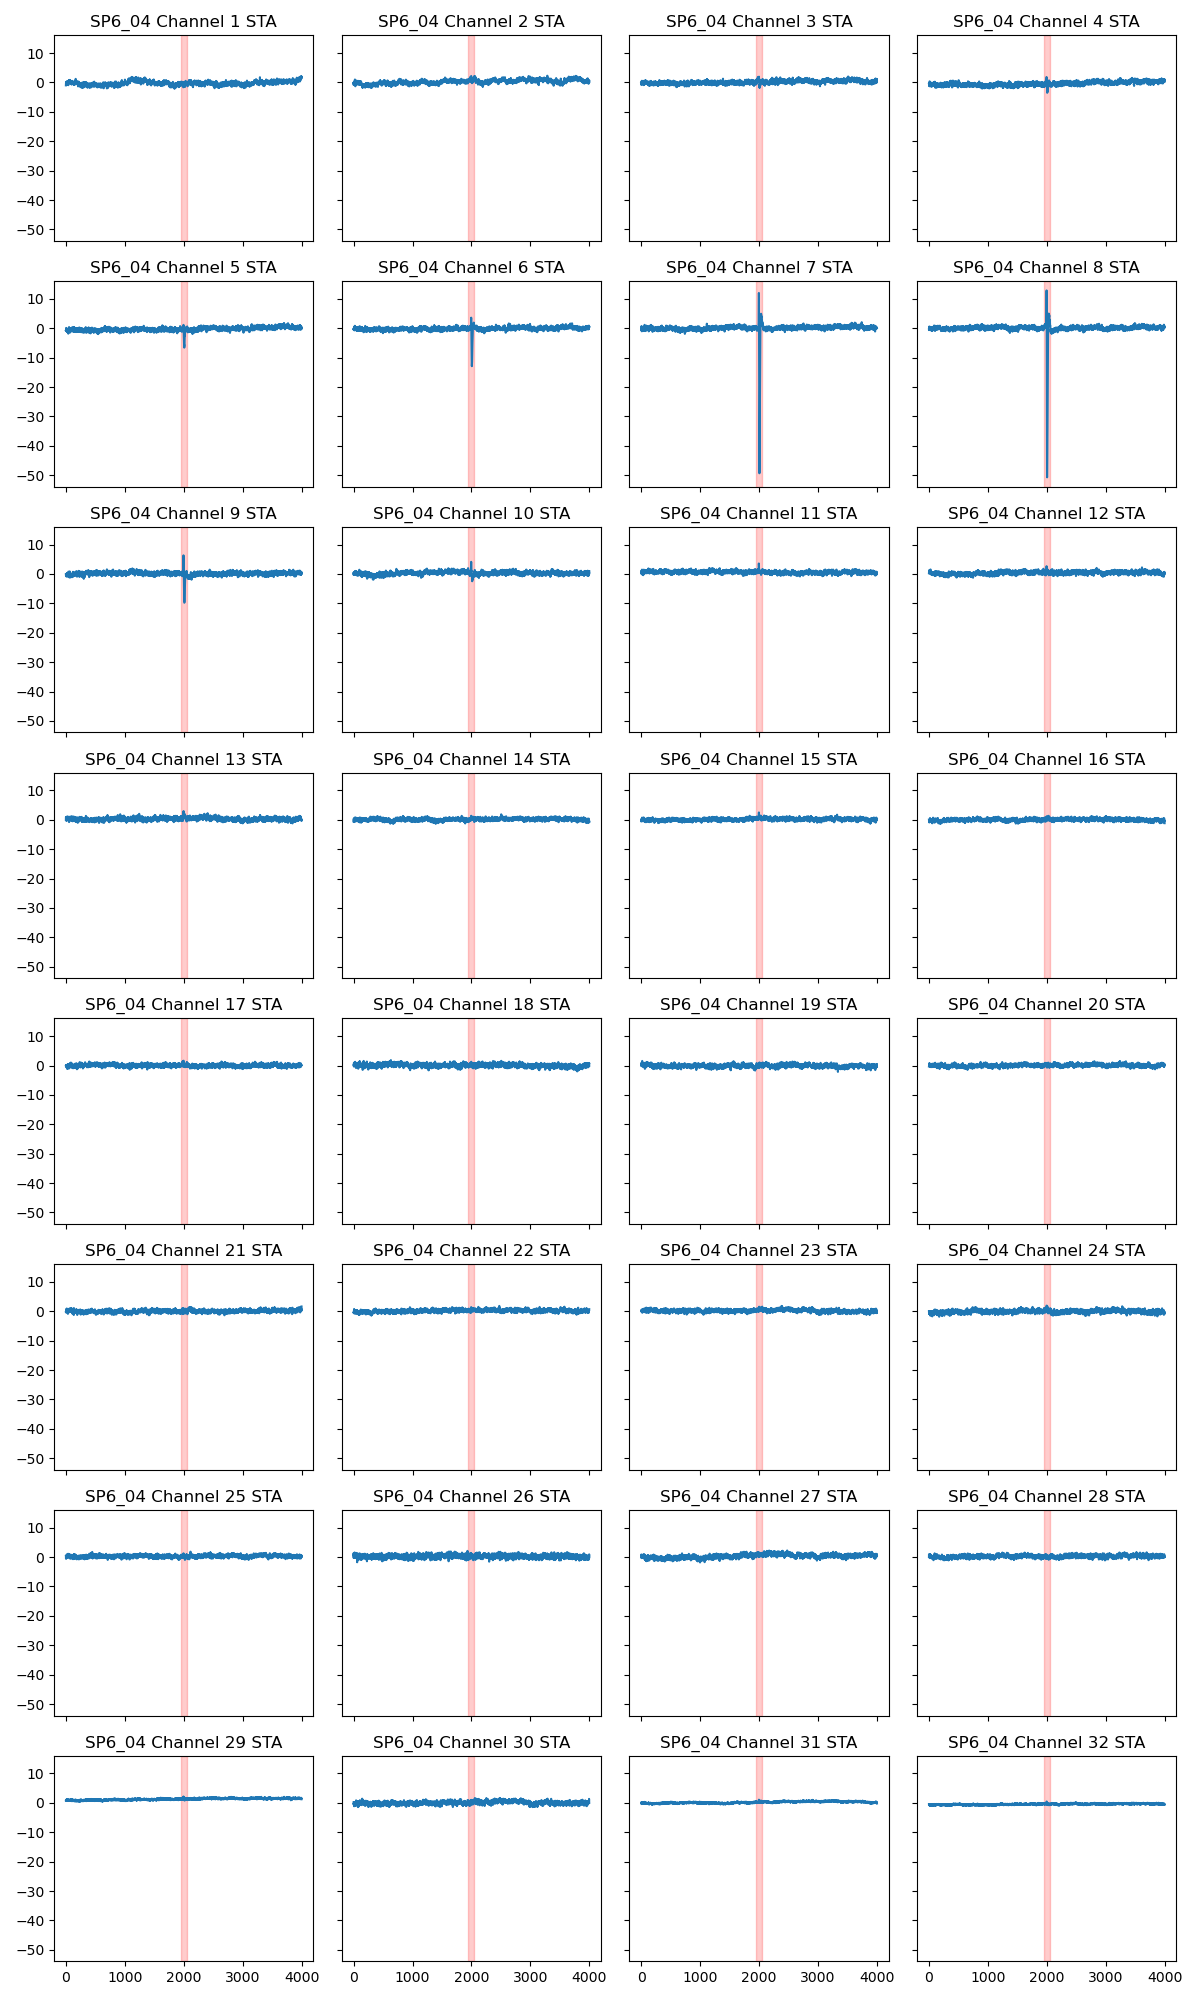

In [12]:
# Plotting the average epochs for channel all 32 channels for SP6 recordings
f, axes = plt.subplots(8, 4, figsize=(12, 20), sharex=True, sharey=True)
for ch in range(32):
    ax = axes[ch // 4, ch % 4]
    ax.plot(sp6_04_avg_epochs[ch])
    ax.set_title(f'SP6_04 Channel {ch+1} STA')
    # ax.axvline(half_window_size, color='r', linestyle='--')  # Mark the spike time
    ax.axvspan(half_window_size-50, half_window_size+50, alpha = 0.2, color='r')
plt.tight_layout()
plt.show()

In [13]:
# We can compare the number of spikes we recorded in all the multiple ways
# Print the theoretical number of spikes for SP6_01 from the excel sheet 
print("SP6_01 Theoretical number of IC spikes from excel sheet: 674")
# Print the number of IC spikes from the '33rd' channel of the EC recording for SP6_01
print("SP6_01 IC - number of spikes:", sp6_01_spiketimes.size)
# See which cluster has the most spikes in SP6_01
max_spikes_index = np.argmax(sp6_num_spikes[1])
print("Cluster with most spikes in SP6_01:")
print("Cluster ID:", sp6_cluster_ids[1][max_spikes_index])
print("Number of spikes:", sp6_num_spikes[1][max_spikes_index])
print("\n")

# Print the theoretical number of spikes for SP6_02 from the excel sheet
print("SP6_02 Theoretical number of IC spikes from excel sheet: 788")
# Print the number of IC spikes from the '33rd' channel of the EC recording for SP6_02
print("SP6_02 IC - number of spikes:", sp6_02_spiketimes.size)
# See which cluster has the most spikes in SP6_02
max_spikes_index = np.argmax(sp6_num_spikes[2])
print("Cluster with most spikes in SP6_02:")
print("Cluster ID:", sp6_cluster_ids[2][max_spikes_index])
print("Number of spikes:", sp6_num_spikes[2][max_spikes_index])
print("\n")

# Print the theoretical number of spikes for SP6_03 from the excel sheet
print("SP6_03 Theoretical number of IC spikes from excel sheet: 232")
# Print the number of IC spikes from the '33rd' channel of the EC recording for SP6_03
print("SP6_03 IC - number of spikes:", sp6_03_spiketimes.size)
# See which cluster has the most spikes in SP6_03
max_spikes_index = np.argmax(sp6_num_spikes[3])
print("Cluster with most spikes in SP6_03:")
print("Cluster ID:", sp6_cluster_ids[3][max_spikes_index])
print("Number of spikes:", sp6_num_spikes[3][max_spikes_index])
print("\n")

# Print the theoretical number of spikes for SP6_04 from the excel sheet
print("SP6_04 Theoretical number of IC spikes from excel sheet: 311")
# Print the number of IC spikes from the '33rd' channel of the EC recording for SP6_04
print("SP6_04 IC - number of spikes:", sp6_04_spiketimes.size)
# See which cluster has the most spikes in SP6_04
max_spikes_index = np.argmax(sp6_num_spikes[4])
print("Cluster with most spikes in SP6_04:")
print("Cluster ID:", sp6_cluster_ids[4][max_spikes_index])
print("Number of spikes:", sp6_num_spikes[4][max_spikes_index])


SP6_01 Theoretical number of IC spikes from excel sheet: 674
SP6_01 IC - number of spikes: 678
Cluster with most spikes in SP6_01:
Cluster ID: 7
Number of spikes: 700


SP6_02 Theoretical number of IC spikes from excel sheet: 788
SP6_02 IC - number of spikes: 793
Cluster with most spikes in SP6_02:
Cluster ID: 8
Number of spikes: 808


SP6_03 Theoretical number of IC spikes from excel sheet: 232
SP6_03 IC - number of spikes: 235
Cluster with most spikes in SP6_03:
Cluster ID: 16
Number of spikes: 238


SP6_04 Theoretical number of IC spikes from excel sheet: 311
SP6_04 IC - number of spikes: 312
Cluster with most spikes in SP6_04:
Cluster ID: 7
Number of spikes: 317


### SP9

In [14]:
# We plot the .mat file with the 32 channels of EC and 1 channel of IC recording from the EC recorder
# as well as the IC spike timestamps from the .ev2 file
# for the SP9 so we can see the waveforms, if it is possible!

# Load the .mat file for each SP9 recording
mat_file_path = {}
for i in range(1, 4):
    mat_file_path[i-1] = f'../sp_9_20220215/{i:02d}.mat'

mat_sp9_01 = sio.loadmat(mat_file_path[0])
mat_sp9_02 = sio.loadmat(mat_file_path[1])
mat_sp9_03 = sio.loadmat(mat_file_path[2])

print("SP9 .mat file keys for recording 01:", mat_sp9_01.keys())

SP9 .mat file keys for recording 01: dict_keys(['__header__', '__version__', '__globals__', 'simultan_data'])


In [15]:
# Access our matrix
sp9_01_data = mat_sp9_01['simultan_data']  # will be a (33, 3599280) numpy array
sp9_02_data = mat_sp9_02['simultan_data']
sp9_03_data = mat_sp9_03['simultan_data']
print(sp9_01_data.shape)  # (33, 3599280)
print(sp9_02_data.shape)
print(sp9_03_data.shape)

(33, 3599280)
(33, 3599280)
(33, 3599280)


In [16]:
# Split the data into EC and IC
sp9_01_EC = sp9_01_data[:32, :]  # First 32 channels are EC
sp9_01_IC = sp9_01_data[32, :]   # Last channel is IC
sp9_02_EC = sp9_02_data[:32, :]  # First 32 channels are EC
sp9_02_IC = sp9_02_data[32, :]   # Last channel is IC
sp9_03_EC = sp9_03_data[:32, :]  # First 32 channels are EC
sp9_03_IC = sp9_03_data[32, :]   # Last channel is IC

print("SP9 recording 01 EC shape:", sp9_01_EC.shape)
print("SP9 recording 01 IC shape:", sp9_01_IC.shape)

SP9 recording 01 EC shape: (32, 3599280)
SP9 recording 01 IC shape: (3599280,)


In [17]:
# Load the timestamps from the .ev2 files
sp9_01_spiketimes = np.loadtxt('/Volumes/AFedor_T7/TTK-NeuroData/sp_9_20220215/01.ev2', usecols=5)
sp9_02_spiketimes = np.loadtxt('/Volumes/AFedor_T7/TTK-NeuroData/sp_9_20220215/02.ev2', usecols=5)
sp9_03_spiketimes = np.loadtxt('/Volumes/AFedor_T7/TTK-NeuroData/sp_9_20220215/03.ev2', usecols=5)
print(sp9_01_spiketimes.shape)  # (678,)
print(sp9_02_spiketimes.shape)
print(sp9_03_spiketimes.shape)

print(sp9_01_spiketimes[:10])  # Print first 10 spike times

(822,)
(760,)
(773,)
[ 4656.  8853. 12194. 20113. 27679. 31673. 36495. 40604. 51191. 53646.]


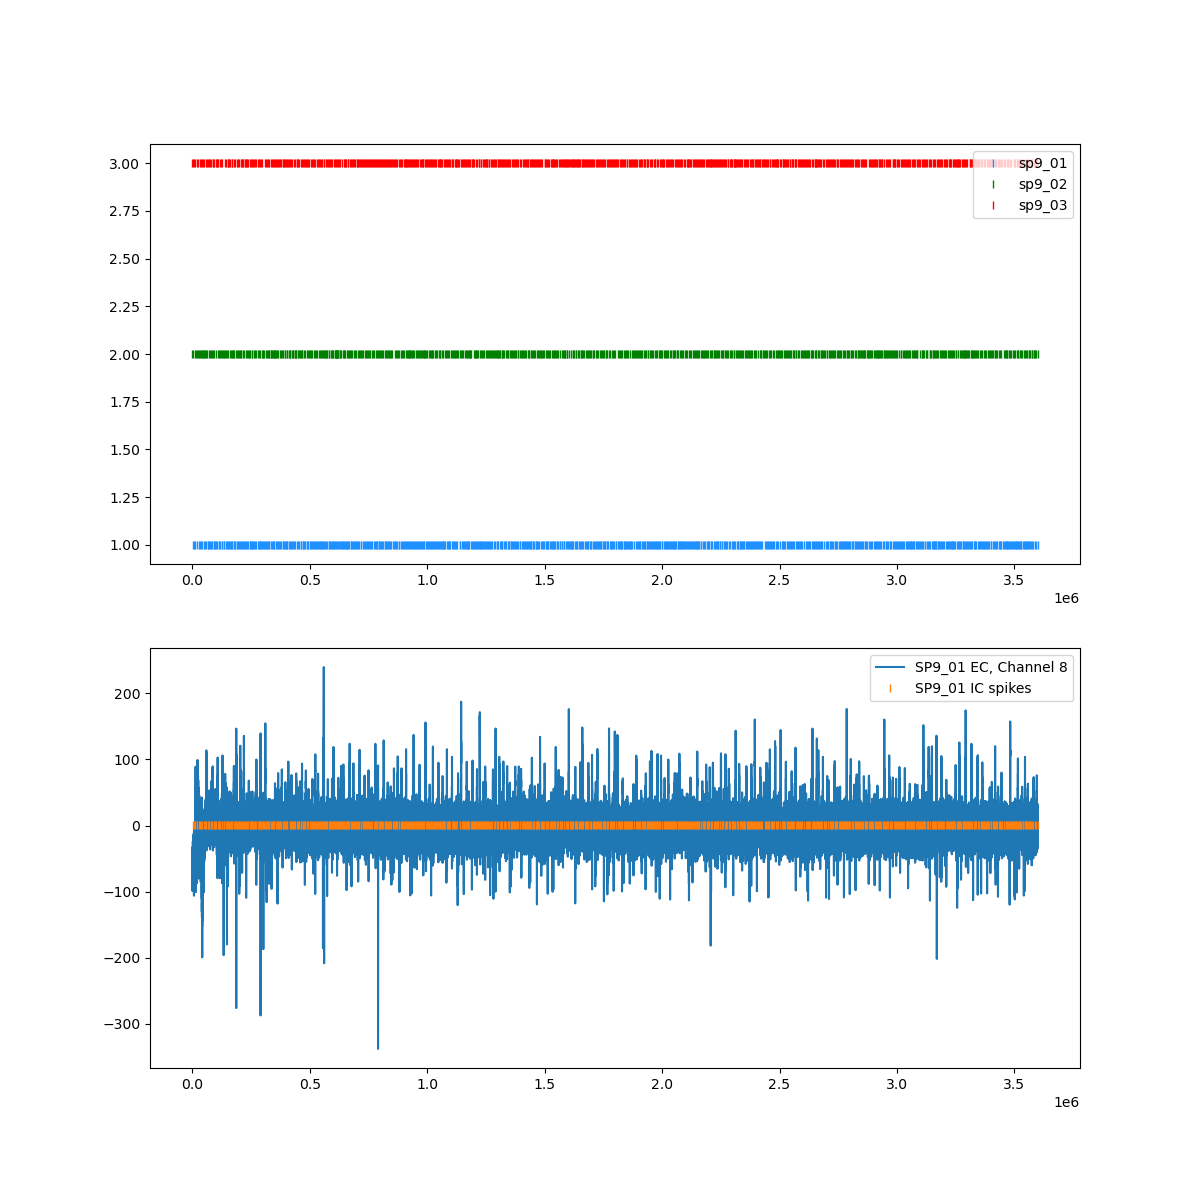

In [18]:
# Plotting some of the data and spike times to see how they look
f, axes = plt.subplots(2, 1, figsize=(12, 12))
axes[0].plot(sp9_01_spiketimes, np.ones_like(sp9_01_spiketimes), '|', label='sp9_01', color='dodgerblue')
axes[0].plot(sp9_02_spiketimes, np.ones_like(sp9_02_spiketimes)*2, '|', label='sp9_02', color='g')
axes[0].plot(sp9_03_spiketimes, np.ones_like(sp9_03_spiketimes)*3, '|', label='sp9_03', color='r')
axes[0].legend()

axes[1].plot(sp9_01_EC[7], label='SP9_01 EC, Channel 8')
axes[1].plot(sp9_01_spiketimes, np.ones_like(sp9_01_spiketimes), '|', label='SP9_01 IC spikes')
axes[1].legend()
plt.show()

In [19]:
# Now I will cut the EC recordings into +- 100ms epochs around each IC spike time
epoch_window = 0.1  # 100 ms
sampling_rate = 20000  # 20 kHz
half_window_size = int(epoch_window * sampling_rate)
print("Half window size in samples:", half_window_size)
print("\n")

# For SP9_01
sp9_01_epochs = np.zeros((32, sp9_01_spiketimes.size, half_window_size * 2))  # Initialize empty array for epochs
for i, spike_time in enumerate(sp9_01_spiketimes):
    start_index = int(spike_time - half_window_size)
    end_index = int(spike_time + half_window_size)
    if start_index >= 0 and end_index <= sp9_01_EC.shape[1]:
        epoch = sp9_01_EC[:, start_index:end_index]
        sp9_01_epochs[:, i, :] = epoch
    elif start_index < 0:
        epoch = sp9_01_EC[:, 0:end_index]
        sp9_01_epochs[:, i, :epoch.shape[1]] = epoch
    elif end_index > sp9_01_EC.shape[1]:
        epoch = sp9_01_EC[:, start_index:sp9_01_EC.shape[1]]
        sp9_01_epochs[:, i, :epoch.shape[1]] = epoch

print("SP9_01 IC - number of spikes:", sp9_01_spiketimes.size)
print("SP9_01_epochs shape:", sp9_01_epochs.shape)  # (32, num_spikes, 4000)
print("\n")

# For SP9_02
sp9_02_epochs = np.zeros((32, sp9_02_spiketimes.size, half_window_size * 2))  # Initialize empty array for epochs
for i, spike_time in enumerate(sp9_02_spiketimes):
    start_index = int(spike_time - half_window_size)
    end_index = int(spike_time + half_window_size)
    if start_index >= 0 and end_index <= sp9_02_EC.shape[1]:
        epoch = sp9_02_EC[:, start_index:end_index]
        sp9_02_epochs[:, i, :] = epoch
    elif start_index < 0:
        epoch = sp9_02_EC[:, 0:end_index]
        sp9_02_epochs[:, i, :epoch.shape[1]] = epoch
    elif end_index > sp9_02_EC.shape[1]:
        epoch = sp9_02_EC[:, start_index:sp9_02_EC.shape[1]]
        sp9_02_epochs[:, i, :epoch.shape[1]] = epoch

print("SP9_02 IC - number of spikes:", sp9_02_spiketimes.size)
print("SP9_02_epochs shape:", sp9_02_epochs.shape)  # (32, num_spikes, 4000)
print("\n")

# For SP9_03
sp9_03_epochs = np.zeros((32, sp9_03_spiketimes.size, half_window_size * 2))  # Initialize empty array for epochs
for i, spike_time in enumerate(sp9_03_spiketimes):
    start_index = int(spike_time - half_window_size)
    end_index = int(spike_time + half_window_size)
    if start_index >= 0 and end_index <= sp9_03_EC.shape[1]:
        epoch = sp9_03_EC[:, start_index:end_index]
        sp9_03_epochs[:, i, :] = epoch
    elif start_index < 0:
        epoch = sp9_03_EC[:, 0:end_index]
        sp9_03_epochs[:, i, :epoch.shape[1]] = epoch
    elif end_index > sp9_03_EC.shape[1]:
        epoch = sp9_03_EC[:, start_index:sp9_03_EC.shape[1]]
        sp9_03_epochs[:, i, :epoch.shape[1]] = epoch

print("SP9_03 IC - number of spikes:", sp9_03_spiketimes.size)
print("SP9_03_epochs shape:", sp9_03_epochs.shape)  # (32, num_spikes, 4000)

Half window size in samples: 2000


SP9_01 IC - number of spikes: 822
SP9_01_epochs shape: (32, 822, 4000)


SP9_02 IC - number of spikes: 760
SP9_02_epochs shape: (32, 760, 4000)


SP9_03 IC - number of spikes: 773
SP9_03_epochs shape: (32, 773, 4000)


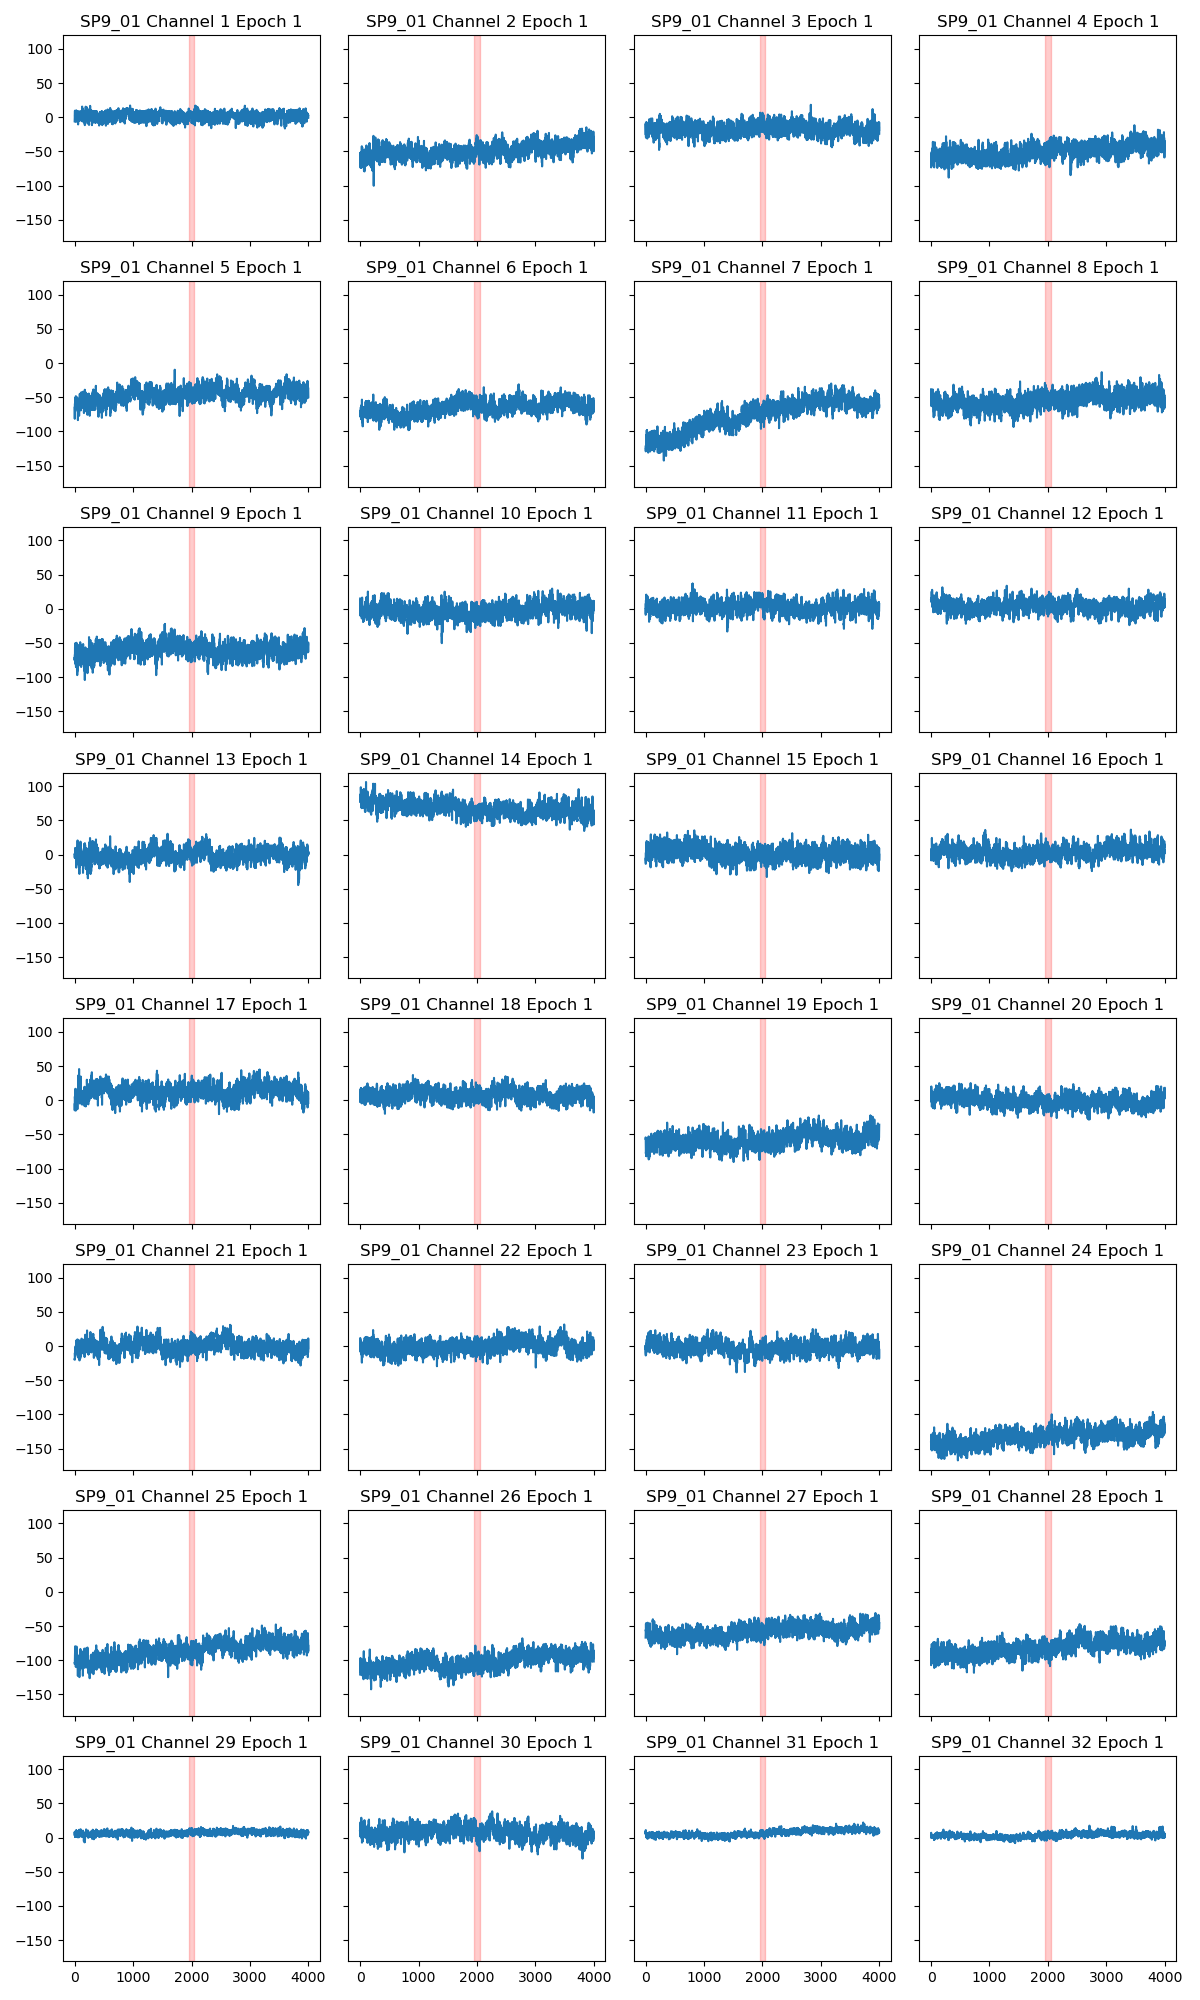

In [20]:
# Plotting an individual epoch for all channels for SP9_01
fig, axes = plt.subplots(8, 4, figsize=(12, 20), sharex=True, sharey=True)
num_of_ch = sp9_01_epochs.shape[0]
for ch in range(32):
    ax = axes[ch // 4, ch % 4]
    ax.plot(sp9_01_epochs[ch, 0, :])
    ax.set_title(f'SP9_01 Channel {ch+1} Epoch 1')
    # ax.axvline(half_window_size, color='r', linestyle='--')  # Mark the spike time
    ax.axvspan(half_window_size-50, half_window_size+50, alpha = 0.2, color='r')
plt.tight_layout()
plt.show()

In [21]:
# Averaging all epochs for each channel in each recording
# to see the average waveform around IC spiketimes
sp9_01_avg_epochs = np.mean(sp9_01_epochs, axis=1)  # Shape: (32, 4000)
sp9_02_avg_epochs = np.mean(sp9_02_epochs, axis=1)  # Shape: (32, 4000)
sp9_03_avg_epochs = np.mean(sp9_03_epochs, axis=1)  # Shape: (32, 4000)

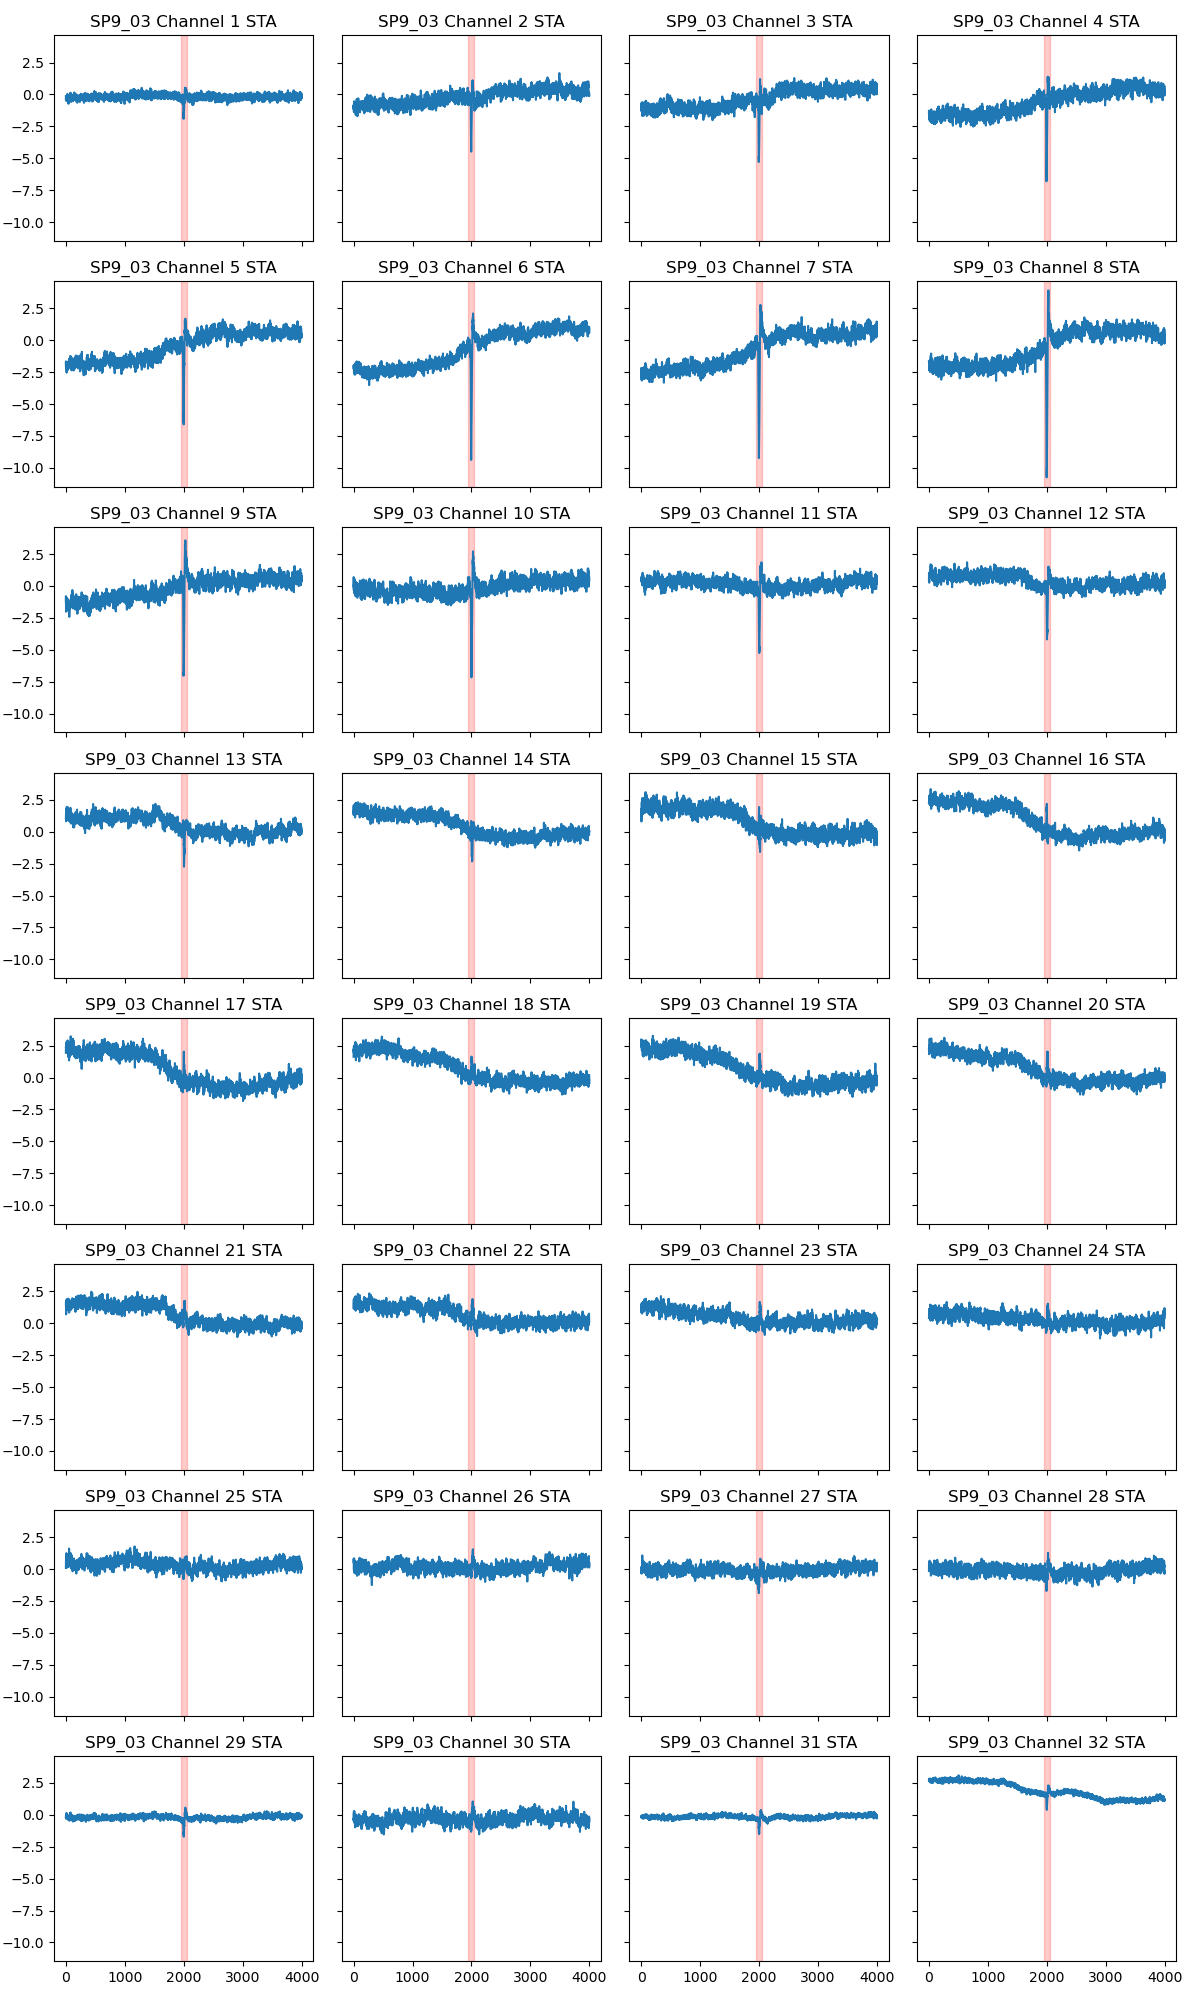

In [22]:
# Plotting the average epochs for channel all 32 channels for SP6 recordings
f, axes = plt.subplots(8, 4, figsize=(12, 20), sharex=True, sharey=True)
for ch in range(32):
    ax = axes[ch // 4, ch % 4]
    ax.plot(sp9_03_avg_epochs[ch])
    ax.set_title(f'SP9_03 Channel {ch+1} STA')
    # ax.axvline(half_window_size, color='r', linestyle='--')  # Mark the spike time
    ax.axvspan(half_window_size-50, half_window_size+50, alpha = 0.2, color='r')
plt.tight_layout()
plt.show()

In [23]:
# We can compare the number of spikes we recorded in all the multiple ways
# Print the theoretical number of spikes for SP9_01 from the excel sheet 
print("SP9_01 Theoretical number of IC spikes from excel sheet: 822")
# Print the number of IC spikes from the '33rd' channel of the EC recording for SP9_01
print("SP9_01 IC - number of spikes:", sp9_01_spiketimes.size)
# See which cluster has the most spikes in SP9_01
# max_spikes_index = np.argmax(sp9_num_spikes[1])
index = np.where(sp9_num_spikes[1] == 836)[0]
print("Cluster with most spikes in SP9_01:")
print("Cluster ID:", sp9_cluster_ids[1][index])
print("Number of spikes:", sp9_num_spikes[1][index])
print("\n")

# Print the theoretical number of spikes for SP9_02 from the excel sheet
print("SP9_02 Theoretical number of IC spikes from excel sheet: 760")
# Print the number of IC spikes from the '33rd' channel of the EC recording for SP9_02
print("SP9_02 IC - number of spikes:", sp9_02_spiketimes.size)
# See which cluster has the most spikes in SP9_02
# max_spikes_index = np.argmax(sp9_num_spikes[2])
index = np.where(sp9_num_spikes[2] == 583)[0]
print("Cluster with most spikes in SP9_02:")
print("Cluster ID:", sp9_cluster_ids[2][index])
print("Number of spikes:", sp9_num_spikes[2][index])
print("\n")

# Print the theoretical number of spikes for SP9_03 from the excel sheet
print("SP9_03 Theoretical number of IC spikes from excel sheet: 773")
# Print the number of IC spikes from the '33rd' channel of the EC recording for SP9_03
print("SP9_03 IC - number of spikes:", sp9_03_spiketimes.size)
# See which cluster has the most spikes in SP9_03
# max_spikes_index = np.argmax(sp9_num_spikes[3])
index = np.where(sp9_num_spikes[3] == 1048)[0]
print("Cluster with most spikes in SP9_03:")
print("Cluster ID:", sp9_cluster_ids[3][index])
print("Number of spikes:", sp9_num_spikes[3][index])

SP9_01 Theoretical number of IC spikes from excel sheet: 822
SP9_01 IC - number of spikes: 822
Cluster with most spikes in SP9_01:
Cluster ID: [133]
Number of spikes: [836]


SP9_02 Theoretical number of IC spikes from excel sheet: 760
SP9_02 IC - number of spikes: 760
Cluster with most spikes in SP9_02:
Cluster ID: [77]
Number of spikes: [583]


SP9_03 Theoretical number of IC spikes from excel sheet: 773
SP9_03 IC - number of spikes: 773
Cluster with most spikes in SP9_03:
Cluster ID: [79]
Number of spikes: [1048]


### Comparing the number of spikes 

In [24]:
# Now we calculate the difference between the theoretical number of spikes and the number of spikes we recorded
# for both SP6 and SP9 recordings
# and make arrays with the number of spikes for plotting later

# SP6
sp6_theoretical_spikes = np.array([674, 788, 232, 311])
sp6_recorded_spikes = np.zeros(4)
for i in range(4):
    index = np.argmax(sp6_num_spikes[i+1])
    sp6_recorded_spikes[i] = sp6_num_spikes[i+1][index]
    print(sp6_recorded_spikes[i])

# SP9
sp9_theoretical_spikes = np.array([822, 760, 773])
sp9_recorded_spikes = np.array([836, 583, 1048])

# Difference calculation
sp6_difference = sp6_recorded_spikes - sp6_theoretical_spikes
sp9_difference = sp9_recorded_spikes - sp9_theoretical_spikes

700.0
808.0
238.0
317.0


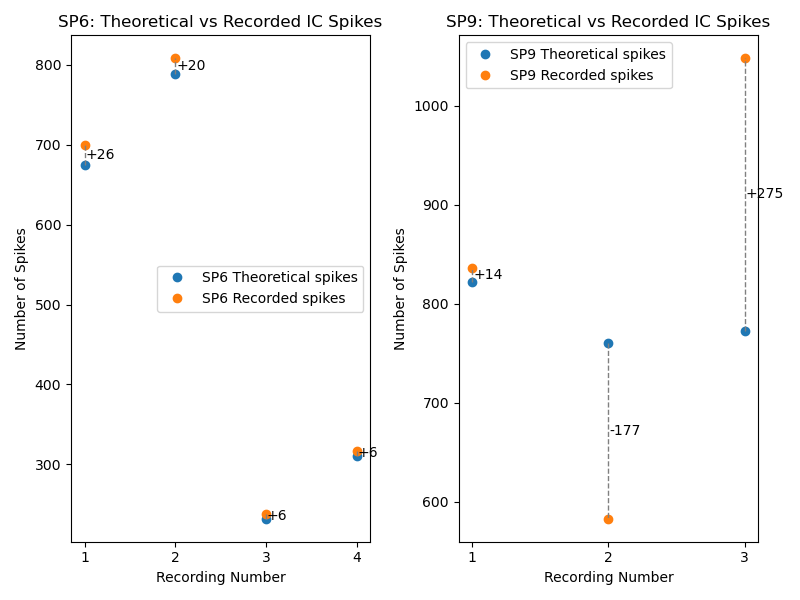

In [27]:
# Now we plot the difference between the manually curated clusters and the spikes labeled here
# We will plot the number of spikes for SP6 and SP9 recordings
f, axes = plt.subplots(1, 2, figsize=(8, 6))

# SP6 subplot
x_sp6 = np.arange(1, 5)
axes[0].plot(x_sp6, sp6_theoretical_spikes, label='SP6 Theoretical spikes', linestyle='None', marker='o')
axes[0].plot(x_sp6, sp6_recorded_spikes, label='SP6 Recorded spikes', linestyle='None', marker='o')

# Add vertical lines with difference annotations for SP6
for i in range(len(x_sp6)):
    y1 = sp6_theoretical_spikes[i]
    y2 = sp6_recorded_spikes[i]
    diff = y2 - y1
    axes[0].plot([x_sp6[i], x_sp6[i]], [y1, y2], color='gray', linestyle='--', linewidth=1)
    mid_y = (y1 + y2) / 2
    axes[0].text(x_sp6[i] + 0.01, mid_y, f'{diff:+.0f}', fontsize=10, va='center')

axes[0].set_title('SP6: Theoretical vs Recorded IC Spikes')
axes[0].set_xlabel('Recording Number')
axes[0].set_ylabel('Number of Spikes')
axes[0].set_xticks(x_sp6)
axes[0].legend()

# SP9 subplot
x_sp9 = np.arange(1, 4)
axes[1].plot(x_sp9, sp9_theoretical_spikes, label='SP9 Theoretical spikes', linestyle='None', marker='o')
axes[1].plot(x_sp9, sp9_recorded_spikes, label='SP9 Recorded spikes', linestyle='None', marker='o')

# Add vertical lines with difference annotations for SP9
for i in range(len(x_sp9)):
    y1 = sp9_theoretical_spikes[i]
    y2 = sp9_recorded_spikes[i]
    diff = y2 - y1
    axes[1].plot([x_sp9[i], x_sp9[i]], [y1, y2], color='gray', linestyle='--', linewidth=1)
    mid_y = (y1 + y2) / 2
    axes[1].text(x_sp9[i] + 0.01, mid_y, f'{diff:+.0f}', fontsize=10, va='center')

axes[1].set_title('SP9: Theoretical vs Recorded IC Spikes')
axes[1].set_xlabel('Recording Number')
axes[1].set_ylabel('Number of Spikes')
axes[1].set_xticks(x_sp9)
axes[1].legend()

plt.tight_layout()
plt.show()

Analysing the clusters made by KiloSort and their manually curated versions

In [51]:
# Printing only the number of good cluster between SP6 and SP9 recordings
for i in range(1, 5):
    good_clusters_sp6 = np.sum(sp6_cluster_types[i] == 'good')
    print(f"SP6 Recording {i:02d} - Number of good clusters: {good_clusters_sp6}")


for i in range(1, 4):
    good_clusters_sp9 = np.sum(sp9_cluster_types[i] == 'good')
    print(f"SP9 Recording {i:02d} - Number of good clusters: {good_clusters_sp9}")

SP6 Recording 01 - Number of good clusters: 6
SP6 Recording 02 - Number of good clusters: 4
SP6 Recording 03 - Number of good clusters: 6
SP6 Recording 04 - Number of good clusters: 6
SP9 Recording 01 - Number of good clusters: 14
SP9 Recording 02 - Number of good clusters: 11
SP9 Recording 03 - Number of good clusters: 17


In [52]:
# Print the cluster types for SP6_04 as an example
print("SP6_04 Cluster Types:")
for cluster_id, cluster_type in zip(sp6_cluster_ids[3], sp6_cluster_types[3]):
    print(f"Cluster ID: {cluster_id}, Type: {cluster_type}")   

SP6_04 Cluster Types:
Cluster ID: 1, Type: good
Cluster ID: 7, Type: noise
Cluster ID: 8, Type: noise
Cluster ID: 9, Type: noise
Cluster ID: 11, Type: noise
Cluster ID: 13, Type: good
Cluster ID: 14, Type: noise
Cluster ID: 15, Type: good
Cluster ID: 16, Type: good
Cluster ID: 17, Type: good
Cluster ID: 18, Type: good
Cluster ID: 19, Type: noise
Cluster ID: 20, Type: noise


### Creating LaTeX tables for the report

In [53]:
# Create DataFrame for spike comparison
spike_comparison_data = {
    'Recording': ['SP6\\_01', 'SP6\\_02', 'SP6\\_03', 'SP6\\_04', 
                  'SP9\\_01', 'SP9\\_02', 'SP9\\_03'],
    'IC Recorded': [674, 788, 232, 311, 822, 760, 773],
    'EC Clustered': [int(sp6_recorded_spikes[0]), int(sp6_recorded_spikes[1]), 
                     int(sp6_recorded_spikes[2]), int(sp6_recorded_spikes[3]),
                     836, 583, 1048],
    'Difference': [int(sp6_difference[0]), int(sp6_difference[1]), 
                   int(sp6_difference[2]), int(sp6_difference[3]),
                   int(sp9_difference[0]), int(sp9_difference[1]), int(sp9_difference[2])]
}

df_spikes = pd.DataFrame(spike_comparison_data)

# Save to LaTeX
latex_table_spikes = df_spikes.to_latex(index=False, 
                                        caption='Comparison of IC recorded spikes vs. EC clustered spikes',
                                        label='tab:spike_comparison',
                                        column_format='lccc',
                                        escape=False)

# Save to file
with open('spike_comparison_table.tex', 'w') as f:
    f.write(latex_table_spikes)

print("Spike Comparison Table:")
print(latex_table_spikes)
print("\nSaved to: spike_comparison_table.tex")

Spike Comparison Table:
\begin{table}
\caption{Comparison of IC recorded spikes vs. EC clustered spikes}
\label{tab:spike_comparison}
\begin{tabular}{lccc}
\toprule
Recording & IC Recorded & EC Clustered & Difference \\
\midrule
SP6\_01 & 674 & 700 & 26 \\
SP6\_02 & 788 & 808 & 20 \\
SP6\_03 & 232 & 238 & 6 \\
SP6\_04 & 311 & 317 & 6 \\
SP9\_01 & 822 & 836 & 14 \\
SP9\_02 & 760 & 583 & -177 \\
SP9\_03 & 773 & 1048 & 275 \\
\bottomrule
\end{tabular}
\end{table}


Saved to: spike_comparison_table.tex


In [57]:
# Create DataFrame for good cluster counts and for the ratio of good clusters to all clusters
# Calculate good clusters, total clusters, and ratios
sp6_good_counts = [
    int(np.sum(sp6_cluster_types[1] == 'good')),
    int(np.sum(sp6_cluster_types[2] == 'good')),
    int(np.sum(sp6_cluster_types[3] == 'good')),
    int(np.sum(sp6_cluster_types[4] == 'good'))
]
sp6_total_counts = [len(sp6_cluster_types[i]) for i in range(1, 5)] 

sp9_good_counts = [
    int(np.sum(sp9_cluster_types[1] == 'good')),
    int(np.sum(sp9_cluster_types[2] == 'good')),
    int(np.sum(sp9_cluster_types[3] == 'good'))
]
sp9_total_counts = [len(sp9_cluster_types[i]) for i in range(1, 4)]

# Calculate ratios and percentages
sp6_ratios = [f'{good}/{total}' for good, total in zip(sp6_good_counts, sp6_total_counts)]
sp9_ratios = [f'{good}/{total}' for good, total in zip(sp9_good_counts, sp9_total_counts)]

sp6_percentages = [f'{(good/total)*100:.1f}\\%' for good, total in zip(sp6_good_counts, sp6_total_counts)]
sp9_percentages = [f'{(good/total)*100:.1f}\\%' for good, total in zip(sp9_good_counts, sp9_total_counts)]

good_cluster_data = {
    'Recording': ['SP6\\_01', 'SP6\\_02', 'SP6\\_03', 'SP6\\_04', 
                  'SP9\\_01', 'SP9\\_02', 'SP9\\_03'],
    'Good Clusters': sp6_good_counts + sp9_good_counts,
    'Total Clusters': sp6_total_counts + sp9_total_counts,
    'Ratio': sp6_ratios + sp9_ratios,
    'Percentage': sp6_percentages + sp9_percentages
}

df_good_clusters = pd.DataFrame(good_cluster_data)

# Save to LaTeX
latex_table_clusters = df_good_clusters.to_latex(index=False, 
                                                  caption='Number of good clusters after manual curation',
                                                  label='tab:good_clusters',
                                                  column_format='lcccc',
                                                  escape=False)

# Save to file
with open('good_clusters_table.tex', 'w') as f:
    f.write(latex_table_clusters)

print("Good Clusters Table:")
print(latex_table_clusters)
print("\nSaved to: good_clusters_table.tex")

Good Clusters Table:
\begin{table}
\caption{Number of good clusters after manual curation}
\label{tab:good_clusters}
\begin{tabular}{lcccc}
\toprule
Recording & Good Clusters & Total Clusters & Ratio & Percentage \\
\midrule
SP6\_01 & 6 & 20 & 6/20 & 30.0\% \\
SP6\_02 & 4 & 13 & 4/13 & 30.8\% \\
SP6\_03 & 6 & 13 & 6/13 & 46.2\% \\
SP6\_04 & 6 & 12 & 6/12 & 50.0\% \\
SP9\_01 & 14 & 35 & 14/35 & 40.0\% \\
SP9\_02 & 11 & 50 & 11/50 & 22.0\% \\
SP9\_03 & 17 & 51 & 17/51 & 33.3\% \\
\bottomrule
\end{tabular}
\end{table}


Saved to: good_clusters_table.tex
